# Supervised Learning: Stock Direction Prediction with Random Forest

In this lesson, we will learn how **supervised learning** works and use it to build a small stock-direction prediction model.

By the end, we will be able to:
- Explain supervised learning.
- Distinguish **classification** from **regression**.
- Understand the intuition behind a **Decision Tree** and **Random Forest**.
- Download real stock-market data using `yfinance`.
- Turn financial data into features and a target.
- Train a Random Forest to classify the next trading day's direction as **UP** or **DOWN**.
- Evaluate the model and inspect feature importance.
- Understand how this becomes the foundation for our next app feature: **correlation-aware stock direction prediction**.

> **Important:** This notebook is for learning machine-learning concepts. It is not financial advice and the model should not be treated as a trading system.

## 1. What Is Supervised Learning?

**Supervised learning** is a type of machine learning where we train a model using historical examples for which the correct answer is already known.

Each example contains two important pieces:

- **Features (`X`)** — the information we give to the model.
- **Target (`y`)** — the answer we want the model to learn to predict.

For a stock-direction model, a historical example could look like this:

| Daily Return | 5-Day Return | Volatility | Tomorrow |
|---:|---:|---:|---|
| +1.2% | +3.1% | 1.8% | UP |
| -0.7% | -2.2% | 2.4% | DOWN |
| +0.4% | +1.5% | 1.6% | UP |

Because these are historical days, we already know whether the stock went up or down the next day. The model studies many such examples and tries to learn relationships between the inputs and the answer.

After training, we can give the model a new row whose answer is unknown and ask it to make a prediction.

### Why is it called *supervised* learning?

During training, the algorithm has the correct answers available. You can think of it as practicing with an answer key.

## 2. Features and Target

Suppose our future application wants to predict whether a stock will move **UP or DOWN on the next trading day**.

### Features — `X`

Features describe what has recently been happening to the stock. Examples include:

- 1-day return
- 5-day return
- 10-day return
- recent volatility
- volume change
- momentum indicators

Later, we will also add information about **highly correlated stocks**.

### Target — `y`

The target is what we want to predict:

- `1` = next trading day's close is higher → **UP**
- `0` = next trading day's close is not higher → **DOWN**

Conceptually:

```text
Stock features (X)
        ↓
Machine-learning model
        ↓
Next-day direction (y)
UP / DOWN
```

## 3. Classification vs. Regression

Supervised-learning problems are commonly divided into **classification** and **regression**.

### Classification

Classification predicts a **category or class**.

Examples:
- Email → Spam / Not Spam
- Transaction → Fraud / Not Fraud
- Patient → Disease / No Disease
- Stock → UP / DOWN

Our next feature is a **binary classification** problem because it has two classes: `UP` and `DOWN`.

### Regression

Regression predicts a **numerical value**.

Examples:
- House → predicted price = $725,000
- Stock → predicted next 5-day return = 2.7%
- Stock → predicted future volatility = 28.4%

### Easy rule to remember

| Question | Type |
|---|---|
| "Which category?" | Classification |
| "What number?" | Regression |

For our project:

> **Will AAPL go UP or DOWN next trading day? → Classification**

If instead we asked:

> **What exact percentage return will AAPL have next trading day? → Regression**

### Quick Check

Decide whether each problem is **classification** or **regression**.

1. Predict whether a customer will cancel a subscription.
2. Predict the price of a house.
3. Predict whether a transaction is fraudulent.
4. Predict a stock's next-month volatility.
5. Predict whether a stock closes higher or lower next trading day.

**Answers:** 1 Classification, 2 Regression, 3 Classification, 4 Regression, 5 Classification.

## 4. From a Decision Tree to a Random Forest

Before understanding a Random Forest, first understand a **Decision Tree**.

A Decision Tree makes predictions by repeatedly splitting observations using feature values.

A simplified stock-direction tree might look like:

```text
             Is 5-Day Return > 2%?
                  /          \
                Yes           No
                /              \
      Is Volatility < 2%?      DOWN
           /       \
         Yes        No
          |          |
          UP        DOWN
```

We do **not** normally write these rules ourselves. During training, the algorithm searches for useful splits in the historical data.

## How Does a Decision Tree Learn?

A Decision Tree learns a set of **questions** that separate the training examples.

Imagine we are predicting whether a stock will go:

- `1` → UP tomorrow
- `0` → DOWN tomorrow

Our training data might look like:

| 5-Day Return | Volatility | Tomorrow |
|---:|---:|---:|
| 4.2% | 1.5% | UP |
| 3.1% | 1.8% | UP |
| -2.5% | 2.9% | DOWN |
| -3.2% | 3.1% | DOWN |
| 1.8% | 1.7% | UP |
| -1.5% | 2.5% | DOWN |

The Decision Tree tries to find questions such as:

**Is 5-Day Return > 0.15%?**

or

**Is Volatility < 2.2%?**

It tests many possible questions and chooses the one that does the best job of
separating UP examples from DOWN examples.

The tree repeats this process for each resulting group.



In [ ]:
import pandas as pd

data = pd.DataFrame({
    "Return_5D": [0.042, 0.031, -0.025, -0.032, 0.018, -0.015],
    "Volatility": [0.015, 0.018, 0.029, 0.031, 0.017, 0.025],
    "Target": [1, 1, 0, 0, 1, 0]
})

data

,Return_5D,Volatility,Target
0,0.042,0.015,1
1,0.031,0.018,1
2,-0.025,0.029,0
3,-0.032,0.031,0
4,0.018,0.017,1
5,-0.015,0.025,0


Here:

- `Return_5D` and `Volatility` are our **features (X)**
- `Target` is our **label (y)**

The Decision Tree's job is to discover rules connecting X to y.

We are NOT telling the tree:

> "Positive returns mean UP."

The tree must discover useful rules from the training data.

## How Does the Tree Choose a Split?

Suppose the tree considers:

**Return_5D > 0?**

This would separate our data into:

### Left Side — Return ≤ 0

| Return | Target |
|---:|---:|
| -2.5% | DOWN |
| -3.2% | DOWN |
| -1.5% | DOWN |

### Right Side — Return > 0

| Return | Target |
|---:|---:|
| 4.2% | UP |
| 3.1% | UP |
| 1.8% | UP |

This is an excellent split because both groups are very **pure**.

One contains only DOWN examples.

The other contains only UP examples.

Decision Trees search for splits that make the resulting groups as pure as
possible.

## Measuring How Good a Split Is

A Decision Tree needs a mathematical way to decide whether one split is better
than another.

One common measurement is called **Gini Impurity**.

Think of it as:

> "How mixed are the classes in this group?"

### Example

A node containing:

UP, UP, UP, UP

is very pure.

Gini ≈ 0

---

A node containing:

UP, DOWN, UP, DOWN

is highly mixed.

Gini is higher.

---

During training, the Decision Tree tries many possible:

**Feature + Threshold**

combinations.

For example:

Return_5D < -1%

Return_5D < 0%

Return_5D < 2%

Volatility < 1.8%

Volatility < 2.5%

...

It chooses the split that produces the biggest improvement in purity.

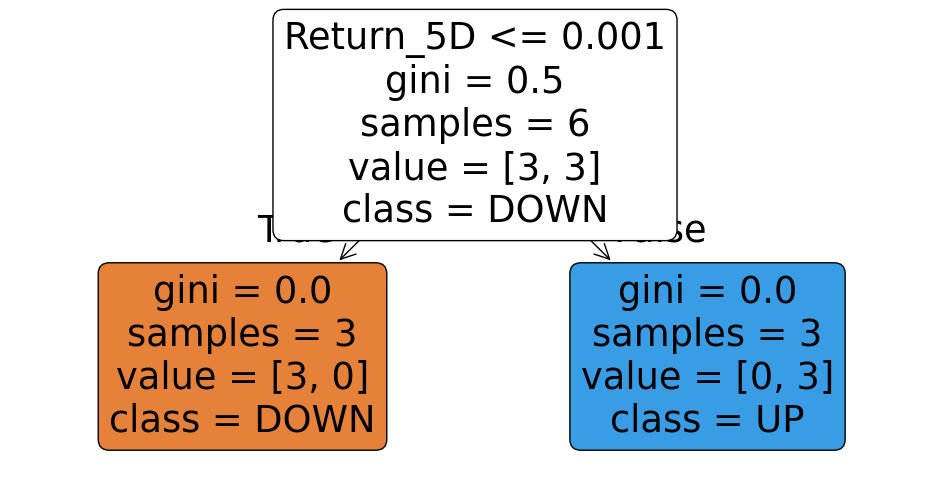

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

X = data[["Return_5D", "Volatility"]]
y = data["Target"]

tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree.fit(X, y)

plt.figure(figsize=(12, 6))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["DOWN", "UP"],
    filled=True,
    rounded=True
)

plt.show()

## What happened when we called `fit()`?

When we ran:

`tree.fit(X, y)`

the Decision Tree roughly performed this process:

1. Look at all available features.
2. Try many possible thresholds for each feature.
3. Measure how well each split separates UP and DOWN.
4. Choose the best split.
5. Divide the training examples into two groups.
6. Repeat the process inside each group.
7. Stop when a stopping condition is reached.

For example:

- maximum depth reached
- node is already pure
- too few samples remain
- another split would not improve the tree enough

So **training a Decision Tree means discovering these rules from the data.**




### Problem with relying on one tree

A single tree can learn very specific patterns from its training data. If it becomes too specialized, it may perform poorly on new data. This is one form of **overfitting**.

## From Decision Tree → Random Forest

Now we understand what ONE Decision Tree does.

It learns rules such as:

                 Return_5D > 0?
                    /       \
                  NO         YES
                  ↓           ↓
                DOWN          UP

But a single Decision Tree can become too dependent on the training data.

A **Random Forest** solves this by training many Decision Trees.

Tree 1 → UP

Tree 2 → UP

Tree 3 → DOWN

Tree 4 → UP

Tree 5 → DOWN

Each tree sees a slightly different sample of the training data and may consider
different features.

For classification, the trees then vote.

Final Prediction → UP

So a Random Forest is essentially:

**Many differently trained Decision Trees working together.**

### Random Forest

A **Random Forest** builds many Decision Trees using randomized samples of the data and randomized subsets of features. For classification, the trees collectively vote on the final class.

```text
                    Stock Features
                         |
        +----------------+----------------+
        |                |                |
      Tree 1           Tree 2           Tree 3
        |                |                |
       UP               DOWN              UP
        |                |                |
        +----------------+----------------+
                         |
                       Voting
                         |
                        UP
```

If 63 of 100 trees favor `UP` and 37 favor `DOWN`, the forest's final classification is `UP`. The model can also return estimated class probabilities.

Random Forest is useful for this project because it:
- handles nonlinear relationships;
- can combine several financial features;
- requires relatively little preprocessing;
- is easier to explain than many boosting models;
- lets us inspect feature importance.

## 5. Important Random Forest Parameters

We will use:

```python
RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
```

### `n_estimators=100`
Build 100 Decision Trees.

### `max_depth=5`
Limit how deep each tree can grow. This controls model complexity and can help reduce overfitting.

### `random_state=42`
Makes the random parts of the experiment reproducible, so rerunning the notebook gives consistent results.

The important idea is not to memorize `42`; it is simply a fixed seed.

# Part 2 — End-to-End Example with Real Stock Data

We will now build a miniature version of the feature we eventually want in our application.

Our first version will use only the target stock's own historical behavior:

```text
AAPL historical prices
        ↓
Feature Engineering
        ↓
1-Day Return
5-Day Return
10-Day Return
20-Day Volatility
        ↓
Random Forest
        ↓
Next Trading Day
UP / DOWN
```

Later, we will add the performance of highly correlated companies as additional features.

## 6. Install and Import Libraries

If `yfinance` or `scikit-learn` is not installed, uncomment the installation line.

In [ ]:
# Uncomment if needed:
# !pip install yfinance pandas numpy scikit-learn matplotlib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)

## 7. Download Real AAPL Data

We will use approximately five years of daily AAPL market data from Yahoo Finance.

Each row represents one trading day. `yfinance` gives us columns such as Open, High, Low, Close, and Volume.

In [ ]:
ticker = "AAPL"

data = yf.download(
    ticker,
    period="5y",
    interval="1d",
    auto_adjust=True,
    progress=False,
)

# yfinance can return a MultiIndex even for one ticker.
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-10-01,139.136703,139.400058,135.683896,138.405175,94639600
2021-10-04,135.713120,138.707516,134.864552,138.268587,98322000
2021-10-05,137.634613,138.736787,135.927714,136.054517,80861100
2021-10-06,138.502716,138.649016,134.962114,136.035028,83221100
2021-10-07,139.760910,140.668013,139.204956,139.536579,61732700


### Inspect the Data

Before doing machine learning, always understand the dataset.

In [ ]:
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
print("Missing values:")
print(data.isna().sum())

Shape: (1254, 5)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Missing values:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## 8. Feature Engineering

Raw closing price alone does not describe recent market behavior very well. We will create four simple features.

### Feature 1 — 1-Day Return
How much did the stock change from the previous trading day's close?

### Feature 2 — 5-Day Return
How much has the stock changed over roughly one trading week?

### Feature 3 — 10-Day Return
A slightly longer momentum measure.

### Feature 4 — 20-Day Volatility
The standard deviation of recent daily returns over 20 trading days. Higher values indicate larger recent price fluctuations.

In [ ]:
data["Return_1D"] = data["Close"].pct_change()
data["Return_5D"] = data["Close"].pct_change(5)
data["Return_10D"] = data["Close"].pct_change(10)
data["Volatility_20D"] = data["Return_1D"].rolling(20).std()

data[[
    "Close",
    "Return_1D",
    "Return_5D",
    "Return_10D",
    "Volatility_20D",
]].tail(10)

Price,Close,Return_1D,Return_5D,Return_10D,Volatility_20D
Date,,,,,
2026-09-17,337.000000,0.013808,0.031938,0.037051,0.014522
2026-09-18,336.130005,-0.002582,0.011617,0.024131,0.013771
2026-09-21,338.980011,0.008479,0.017714,0.059412,0.013590
2026-09-22,339.750000,0.002271,0.025382,0.074410,0.013596
2026-09-23,337.019989,-0.008035,0.013868,0.068751,0.013830
2026-09-24,335.920013,-0.003264,-0.003205,0.028631,0.013820
2026-09-25,341.070007,0.015331,0.014697,0.026485,0.014069
2026-09-28,338.399994,-0.007828,-0.001711,0.015972,0.014007
2026-09-29,329.399994,-0.026596,-0.030464,-0.005855,0.015294


## 9. Create the Target

Now we create the answer that supervised learning will learn from.

For every historical trading day, ask:

> Was the **next trading day's closing price** higher than today's closing price?

- Yes → `Target = 1` → UP
- No → `Target = 0` → DOWN

We use `shift(-1)` to bring the next row's closing price onto the current row.

**Important:** the final row has no known next-day close in our downloaded dataset, so we explicitly remove it rather than accidentally labeling it as DOWN.

In [ ]:
data["Tomorrow_Close"] = data["Close"].shift(-1)

# Remove the last row because its future close is unknown.
data = data[data["Tomorrow_Close"].notna()].copy()

data["Target"] = (
    data["Tomorrow_Close"] > data["Close"]
).astype(int)

data[["Close", "Tomorrow_Close", "Target"]].tail(10)

Price,Close,Tomorrow_Close,Target
Date,,,
2026-09-16,332.410004,337.000000,1
2026-09-17,337.000000,336.130005,0
2026-09-18,336.130005,338.980011,1
2026-09-21,338.980011,339.750000,1
2026-09-22,339.750000,337.019989,0
2026-09-23,337.019989,335.920013,0
2026-09-24,335.920013,341.070007,1
2026-09-25,341.070007,338.399994,0
2026-09-28,338.399994,329.399994,0


## 10. Build the Machine-Learning Dataset

Rolling features create missing values near the beginning because, for example, we cannot calculate 20-day volatility until enough observations exist.

We remove those incomplete rows and then separate our data into:

- `X` → features
- `y` → target

In [ ]:
feature_columns = [
    "Return_1D",
    "Return_5D",
    "Return_10D",
    "Volatility_20D",
]

model_data = data[feature_columns + ["Target"]].dropna().copy()

X = model_data[feature_columns]
y = model_data["Target"]

print("Usable rows:", len(model_data))
print("
Target distribution:")
print(y.value_counts())
print("
Target percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

model_data.head()

## 11. Chronological Train/Test Split

Stock data is time ordered. We train on the older observations and test on newer observations.

We will use:
- first 80% → training
- final 20% → testing

We **do not shuffle** the observations.

In [ ]:
split_index = int(len(model_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Training period:", X_train.index.min().date(), "to", X_train.index.max().date())
print("Testing period:", X_test.index.min().date(), "to", X_test.index.max().date())

## 12. Train the Random Forest

`fit()` is the step where the model learns from historical examples.

We provide:
- `X_train` → historical feature values
- `y_train` → the correct UP/DOWN answers

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
)

model.fit(X_train, y_train)

print("Random Forest trained successfully.")

## 13. Make Predictions

The model has not trained on `X_test`. We now ask it to classify those newer observations.

In [ ]:
predictions = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions,
}, index=y_test.index)

results["Actual_Label"] = results["Actual"].map({0: "DOWN", 1: "UP"})
results["Predicted_Label"] = results["Predicted"].map({0: "DOWN", 1: "UP"})

results.head(15)

## 14. Evaluate the Model

We have already studied evaluation metrics, so here we will apply them rather than re-derive them.

Remember: a model producing predictions does **not** automatically mean it has learned something useful. We need to compare its performance with a simple baseline.

In [ ]:
accuracy = accuracy_score(y_test, predictions)

print(f"Random Forest Accuracy: {accuracy:.2%}
")
print(classification_report(
    y_test,
    predictions,
    target_names=["DOWN", "UP"],
    zero_division=0,
))

### Confusion Matrix

This shows the types of correct and incorrect classifications.

In [ ]:
cm = confusion_matrix(y_test, predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["DOWN", "UP"],
)

display.plot()
plt.title("Random Forest — Confusion Matrix")
plt.show()

## 15. Compare Against a Simple Baseline

A useful ML model should be compared with something simple.

Here our baseline always predicts the most common class in the **training data**.

In [ ]:
majority_class = y_train.mode()[0]
baseline_predictions = np.full(len(y_test), majority_class)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Training majority class:", "UP" if majority_class == 1 else "DOWN")
print(f"Baseline Accuracy:      {baseline_accuracy:.2%}")
print(f"Random Forest Accuracy: {accuracy:.2%}")

if accuracy > baseline_accuracy:
    print("
The Random Forest beat this simple baseline on the test period.")
elif accuracy < baseline_accuracy:
    print("
The simple baseline beat the Random Forest on the test period.")
else:
    print("
The Random Forest and baseline had the same accuracy.")

## 16. Prediction Probability

`predict()` gives us the final class. `predict_proba()` gives us the model's estimated probability for each class.

For this model:
- column 0 corresponds to DOWN
- column 1 corresponds to UP

A value such as `0.61` for UP means the model assigns an estimated 61% probability to the UP class for that observation. It is **not a guarantee** that the stock will rise.

In [ ]:
probabilities = model.predict_proba(X_test)

probability_results = pd.DataFrame({
    "Actual": y_test.map({0: "DOWN", 1: "UP"}),
    "Predicted": pd.Series(predictions, index=y_test.index).map({0: "DOWN", 1: "UP"}),
    "Probability_DOWN": probabilities[:, 0],
    "Probability_UP": probabilities[:, 1],
}, index=y_test.index)

probability_results.tail(10)

## 17. Which Features Did the Random Forest Use Most?

Random Forest exposes a simple feature-importance measure.

A larger value means the feature was used more heavily when the trees made their splits.

**Important:** feature importance does **not** prove causation. It only tells us how much the trained model relied on that feature according to this importance measure.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": model.feature_importances_,
}).sort_values("Importance", ascending=False)

feature_importance

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 18. What Did We Just Build?

We took ordinary market data and converted it into a supervised-learning classification problem:

```text
Yahoo Finance
      ↓
AAPL Historical Prices
      ↓
Feature Engineering
      ↓
Return_1D
Return_5D
Return_10D
Volatility_20D
      ↓
Known Historical Target
UP / DOWN next trading day
      ↓
Older data → Train Random Forest
      ↓
Newer data → Test Random Forest
      ↓
Prediction
UP / DOWN
```

The key idea is that historical data gives us both the **features** and the **known answer**, allowing the model to learn a supervised relationship.

# Part 3 — How This Becomes Our Next App Feature

The model above only looks at the target company's own historical behavior.

Our actual application feature will extend this idea.

Suppose the user wants a prediction for **AAPL**.

First, we can find other companies whose historical returns have had a high correlation with AAPL. Then we can measure how those companies have been performing recently.

The future feature may look like:

```text
                    AAPL
                      |
          +-----------+-----------+
          |                       |
   AAPL's own features      Correlated-stock features
          |                       |
   1-Day Return             Avg 1-Day Return
   5-Day Return             Avg 5-Day Return
   10-Day Return            % Correlated Stocks UP
   Volatility               Other aggregate signals
          |                       |
          +-----------+-----------+
                      |
                Random Forest
                      |
             Next-Day Direction
                      |
                  UP / DOWN
```

### Why add correlated-company information?

The target company's own history may not contain all useful information. Other companies that frequently move in a similar way may provide additional context.

For example, instead of the model seeing only:

```text
AAPL 5-Day Return = +2.1%
```

it could also see:

```text
Average 1-Day Return of highly correlated stocks = +0.8%
Average 5-Day Return of highly correlated stocks = +2.4%
80% of highly correlated stocks are currently UP
```

These become **additional features**. The Random Forest decides whether they are useful for predicting the target.

We should not assume that correlated-stock features improve prediction. We will test this experimentally by comparing model performance **before and after** adding them.

## 19. Important Warning About Correlation and Future Information

When we build the correlation-aware version, we must avoid using information that would not have been available at prediction time.

If we are making a prediction using information available on a particular date, we cannot calculate features using prices from future dates.

A future implementation could calculate correlation using only a historical rolling window, such as the previous 60 or 90 trading days.

```text
Previous 90 trading days
        ↓
Calculate correlations
        ↓
Select highly correlated stocks
        ↓
Measure their recent performance
        ↓
Create features
        ↓
Predict the NEXT trading day
```

This preserves the basic rule:

> **A prediction may only use information that would have been known at the time the prediction was made.**

## 20. Review Questions

1. What makes supervised learning different from unsupervised learning?
2. What is the difference between a feature and a target?
3. Is stock UP/DOWN prediction classification or regression? Why?
4. What would change if we predicted the exact next-day percentage return instead?
5. What is a Decision Tree?
6. Why does a Random Forest use many trees instead of relying on one?
7. What does `n_estimators=100` mean?
8. What does `model.fit(X_train, y_train)` do?
9. What is the difference between `predict()` and `predict_proba()`?
10. Why do we compare the Random Forest with a baseline?
11. Does high feature importance prove that a feature causes the stock to move?
12. How could correlated-company performance become an additional model feature?
13. Why must correlation calculations avoid future data?

## 21. Key Takeaways

- **Supervised learning** learns from examples that contain known answers.
- **Classification** predicts categories; **regression** predicts numerical values.
- Stock direction prediction is a **binary classification** problem.
- A **Decision Tree** learns a sequence of feature-based decisions.
- A **Random Forest** combines many randomized Decision Trees and uses their collective predictions.
- Real financial time-series data can be converted into an ML dataset through **feature engineering** and creation of a **target**.
- A model must be evaluated on newer, unseen observations and compared with a simple baseline.
- Model probabilities are estimates, not guarantees.
- Feature importance describes model usage, not causation.
- Our next feature will extend this classifier with the recent performance of **historically correlated companies**.
- We will test whether those extra features actually improve out-of-sample performance rather than assuming that they do.